In [1]:
import statsmodels.api as sm
import pickle
import json
import gzip
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import mean_squared_error, r2_score, classification_report, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    confusion_matrix,
    classification_report
)
import numpy as np

# zadanie 1

In [24]:
data = pd.read_csv("advertising.csv")
X = data.drop('Sales', axis=1)
y = data['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [25]:

knn_raw = KNeighborsRegressor(n_neighbors=5)
knn_raw.fit(X_train, y_train)

y_pred_raw = knn_raw.predict(X_test)

rmse_raw = np.sqrt(mean_squared_error(y_test, y_pred_raw))
r2_raw = r2_score(y_test, y_pred_raw)
print(f"--- Model na danych surowych ---")
print(f"RMSE: {rmse_raw:.4f}")
print(f"R2  : {r2_raw:.4f}")

--- Model na danych surowych ---
RMSE: 1.7651
R2  : 0.8992


In [4]:
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_scaled = KNeighborsRegressor(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)

y_pred_scaled = knn_scaled.predict(X_test_scaled)

rmse_scaled = np.sqrt(mean_squared_error(y_test, y_pred_scaled))
r2_scaled = r2_score(y_test, y_pred_scaled)

print(f"\n--- Model na danych przeskalowanych ---")
print(f"RMSE: {rmse_scaled:.4f}")
print(f"R2  : {r2_scaled:.4f}")


--- Model na danych przeskalowanych ---
RMSE: 1.7263
R2  : 0.9036


# zadanie 2

In [5]:
data = pd.read_csv("bank.csv")

data.head()


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [6]:

X = data.drop('deposit', axis=1)
y = data['deposit'].map({'yes': 1, 'no': 0})


categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])


pipeline.fit(X_train, y_train)


y_pred_proba = pipeline.predict_proba(X_test)[:, 1]



In [7]:
# Porównanie wyników dla różnych progów
thresholds = [0.1, 0.25, 0.5, 0.75, 0.9]

print("=== Porównanie wyników dla różnych progów ===\n")

results = []
for threshold in thresholds:

    y_pred = (y_pred_proba >= threshold).astype(int)


    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    results.append({
        'Threshold': threshold,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    })

    print(f"Próg: {threshold}")
    print(f"  Accuracy : {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall   : {recall:.4f}")
    print(f"  F1 Score : {f1:.4f}")
    print()


results_df = pd.DataFrame(results)

print(results_df.to_string(index=False))

=== Porównanie wyników dla różnych progów ===

Próg: 0.1
  Accuracy : 0.6413
  Precision: 0.5695
  Recall   : 0.9953
  F1 Score : 0.7245

Próg: 0.25
  Accuracy : 0.8016
  Precision: 0.7195
  Recall   : 0.9527
  F1 Score : 0.8198

Próg: 0.5
  Accuracy : 0.8253
  Precision: 0.8275
  Recall   : 0.7977
  F1 Score : 0.8123

Próg: 0.75
  Accuracy : 0.7662
  Precision: 0.8873
  Recall   : 0.5803
  F1 Score : 0.7017

Próg: 0.9
  Accuracy : 0.6771
  Precision: 0.9181
  Recall   : 0.3497
  F1 Score : 0.5065

 Threshold  Accuracy  Precision   Recall  F1 Score
      0.10  0.641290   0.569497 0.995274  0.724458
      0.25  0.801612   0.719486 0.952741  0.819845
      0.50  0.825347   0.827451 0.797732  0.812320
      0.75  0.766234   0.887283 0.580340  0.701714
      0.90  0.677116   0.918114 0.349716  0.506502


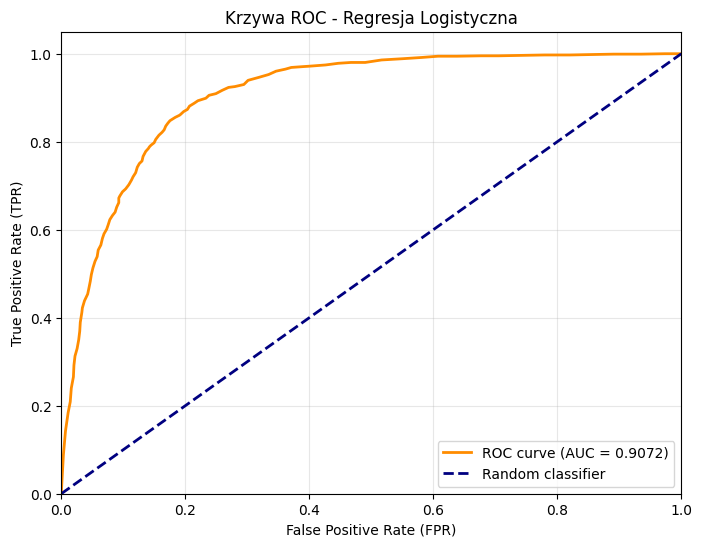

AUC Score: 0.9072


In [8]:
# Obliczenie TPR i FPR dla progów od 0 do 1 co 0.01
thresholds_roc = np.arange(0, 1.01, 0.01)
tpr_list = []
fpr_list = []

for threshold in thresholds_roc:
    y_pred = (y_pred_proba >= threshold).astype(int)

    # Obliczenie macierzy pomyłek
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    # TPR (True Positive Rate) = Recall = TP / (TP + FN)
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0

    # FPR (False Positive Rate) = FP / (FP + TN)
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

    tpr_list.append(tpr)
    fpr_list.append(fpr)

# Obliczenie AUC
roc_auc = auc(fpr_list, tpr_list)

# Rysowanie krzywej ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr_list, tpr_list, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Krzywa ROC - Regresja Logistyczna')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

print(f"AUC Score: {roc_auc:.4f}")

=== Optymalny próg z uwzględnieniem kosztów ===
Koszt False Positive (FP): 10
Koszt False Negative (FN): 3

Optymalny próg: 0.74
Liczba FP: 81
Liczba FN: 433
Całkowity koszt: 2109


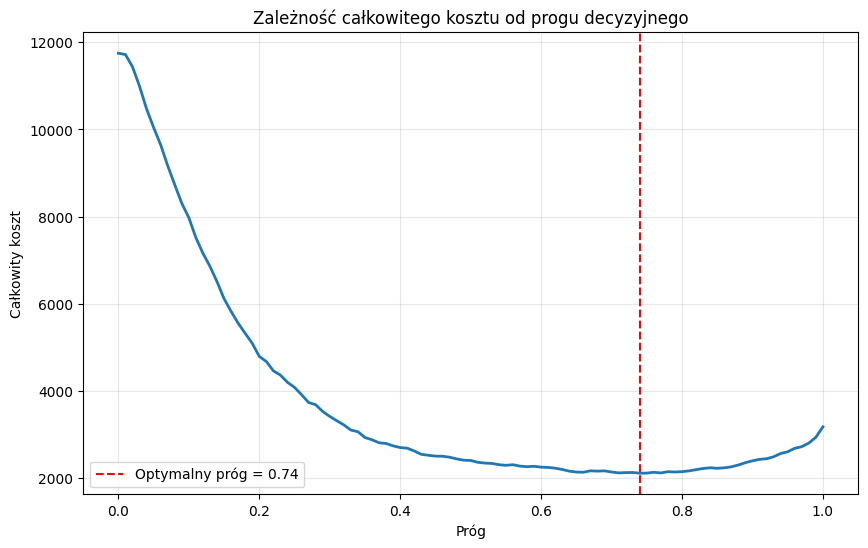

In [9]:

cost_fp = 10
cost_fn = 3

thresholds_cost = np.arange(0, 1.01, 0.01)
costs = []

for threshold in thresholds_cost:
    y_pred = (y_pred_proba >= threshold).astype(int)


    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    # Całkowity koszt = (liczba FP * koszt FP) + (liczba FN * koszt FN)
    total_cost = (fp * cost_fp) + (fn * cost_fn)

    costs.append({
        'Threshold': threshold,
        'FP': fp,
        'FN': fn,
        'Total_Cost': total_cost
    })

# Znalezienie optymalnego progu (minimalny koszt)
costs_df = pd.DataFrame(costs)
optimal_idx = costs_df['Total_Cost'].idxmin()
optimal_threshold = costs_df.loc[optimal_idx, 'Threshold']
optimal_cost = costs_df.loc[optimal_idx, 'Total_Cost']
optimal_fp = costs_df.loc[optimal_idx, 'FP']
optimal_fn = costs_df.loc[optimal_idx, 'FN']

print("=== Optymalny próg z uwzględnieniem kosztów ===")
print(f"Koszt False Positive (FP): {cost_fp}")
print(f"Koszt False Negative (FN): {cost_fn}")
print(f"\nOptymalny próg: {optimal_threshold:.2f}")
print(f"Liczba FP: {optimal_fp}")
print(f"Liczba FN: {optimal_fn}")
print(f"Całkowity koszt: {optimal_cost:.0f}")

# Wykres zależności kosztu od progu
plt.figure(figsize=(10, 6))
plt.plot(costs_df['Threshold'], costs_df['Total_Cost'], linewidth=2)
plt.axvline(x=optimal_threshold, color='red', linestyle='--', label=f'Optymalny próg = {optimal_threshold:.2f}')
plt.xlabel('Próg')
plt.ylabel('Całkowity koszt')
plt.title('Zależność całkowitego kosztu od progu decyzyjnego')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# zadanie 3

In [10]:
# pass

# zadanie 4

In [11]:
import warnings

warnings.filterwarnings("ignore")

In [12]:
data = pd.read_csv("adult.csv", na_values='?')
data = data.dropna()
y = data['income'].str.strip().apply(lambda x: 1 if x == '>50K' else 0)
X = data.drop('income', axis=1)
X_processed = pd.get_dummies(X, drop_first=True)
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
scaler = StandardScaler()
X_processed[numeric_features] = scaler.fit_transform(X_processed[numeric_features])

X_final = sm.add_constant(X_processed, prepend=False)
X_final = X_final.astype(float)

In [13]:
# a)
X_base = X_final[['const']]
base_model = sm.Logit(y, X_base)
base_result = base_model.fit(disp=0)
baseline_aic = base_result.aic
print(f"Bazowy AIC: {baseline_aic:.4f}")

Bazowy AIC: 33852.7085


In [14]:
# b)
predictors_to_check = list(X_final.columns)
predictors_to_check.remove('const')
aic_results = {}

for var in predictors_to_check:
    X_test = X_final[['const', var]]

    model = sm.Logit(y, X_test)
    result = model.fit(disp=0)

    aic_results[var] = result.aic

sorted_results = sorted(aic_results.items(), key=lambda item: item[1])

for var, aic in sorted_results[:10]:
    print(f"Zmienna: {var:<40} | Nowy AIC: {aic:.4f}")

best_var_step1, best_aic_step1 = sorted_results[0]

# c) -> to pierwsze
# d) -> ma sens

Zmienna: marital.status_Married-civ-spouse        | Nowy AIC: 27461.2561
Zmienna: marital.status_Never-married             | Nowy AIC: 30086.6719
Zmienna: education.num                            | Nowy AIC: 30113.2228
Zmienna: capital.gain                             | Nowy AIC: 30702.7992
Zmienna: relationship_Own-child                   | Nowy AIC: 31606.2132
Zmienna: age                                      | Nowy AIC: 32116.1863
Zmienna: hours.per.week                           | Nowy AIC: 32236.1310
Zmienna: sex_Male                                 | Nowy AIC: 32290.6191
Zmienna: relationship_Not-in-family               | Nowy AIC: 32577.7223
Zmienna: occupation_Exec-managerial               | Nowy AIC: 32633.3229


In [15]:
# e)
current_selected = [best_var_step1]

remaining_to_check = list(X_final.columns)
remaining_to_check.remove('const')
remaining_to_check.remove(best_var_step1)

X_model_step1 = X_final[current_selected + ['const']]
result_step1 = sm.Logit(y, X_model_step1).fit(disp=0)
best_aic = result_step1.aic

print(f"--- Model po kroku 1 ---")
print(f"Zmienne: {current_selected}")
print(f"AIC: {best_aic:.4f}")

--- Model po kroku 1 ---
Zmienne: ['marital.status_Married-civ-spouse']
AIC: 27461.2561


In [16]:
aic_results_step2 = {}
failed_vars = []

for var in remaining_to_check:
    try:
        test_vars = current_selected + [var]
        X_test = X_final[test_vars + ['const']]


        model = sm.Logit(y, X_test)
        result = model.fit(disp=0)

        aic_results_step2[var] = result.aic
    except Exception as e:
        failed_vars.append(var)
        continue

sorted_results = sorted(aic_results_step2.items(), key=lambda item: item[1])

for var, aic in sorted_results[:10]:
    print(f"Zmienna: {var:<40} | Nowy AIC: {aic:.4f}")

Zmienna: education.num                            | Nowy AIC: 23903.9184
Zmienna: capital.gain                             | Nowy AIC: 24872.8712
Zmienna: occupation_Prof-specialty                | Nowy AIC: 26520.9379
Zmienna: occupation_Exec-managerial               | Nowy AIC: 26568.1534
Zmienna: education_Bachelors                      | Nowy AIC: 26585.4920
Zmienna: education_Masters                        | Nowy AIC: 26744.9505
Zmienna: education_HS-grad                        | Nowy AIC: 26748.8685
Zmienna: hours.per.week                           | Nowy AIC: 26765.0617
Zmienna: occupation_Other-service                 | Nowy AIC: 26934.9542
Zmienna: age                                      | Nowy AIC: 26978.8695


# zadanie 5

In [17]:
data = pd.read_csv('Titanic Dataset.csv')
data.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [18]:
missing_percentage = (data.isnull().sum() / len(data) * 100).sort_values(ascending=False)

print(missing_percentage[missing_percentage > 0])

body         90.756303
cabin        77.463713
boat         62.872422
home.dest    43.086325
age          20.091673
embarked      0.152788
fare          0.076394
dtype: float64


In [19]:
# b)
print("--- Zależność: Braki w 'age' vs Zmienne Czynnikowe ---")

# Tworzymy tymczasową kolumnę: 1 jeśli 'age' brakuje, 0 jeśli nie
data['age_is_missing'] = data['age'].isnull().astype(int)

# Sprawdzamy, czy średni procent braków w 'age' różni się dla:
# Pclass (Klasa pasażera)
print("\n% braków 'age' w zależności od Pclass:")
print(data.groupby('pclass')['age_is_missing'].mean() * 100)

#  Sex (Płeć)
print("\n% braków 'age' w zależności od Sex:")
print(data.groupby('sex')['age_is_missing'].mean() * 100)

# Embarked (Port zaokrętowania)
print("\n% braków 'age' w zależności od Embarked:")
print(data.groupby('embarked')['age_is_missing'].mean() * 100)

--- Zależność: Braki w 'age' vs Zmienne Czynnikowe ---

% braków 'age' w zależności od Pclass:
pclass
1    12.074303
2     5.776173
3    29.337094
Name: age_is_missing, dtype: float64

% braków 'age' w zależności od Sex:
sex
female    16.738197
male      21.945433
Name: age_is_missing, dtype: float64

% braków 'age' w zależności od Embarked:
embarked
C    21.481481
Q    59.349593
S    14.442013
Name: age_is_missing, dtype: float64


In [20]:
# widzimy wysokosa zaleznosc dla pclass i embarked (3, Q)

In [21]:
# c)
data_baseline = data.copy()
cols_to_drop = ['body', 'cabin', 'boat', 'home.dest']
data_baseline = data_baseline.drop(columns=cols_to_drop)

numeric_with_na = ['age', 'fare']
for col in numeric_with_na:
    mean_value = data_baseline[col].mean()
    data_baseline[col] = data_baseline[col].fillna(mean_value)

categorical_with_na = ['embarked']
for col in categorical_with_na:
    # .mode()[0] zwraca najczęstszą wartość
    mode_value = data_baseline[col].mode()[0]
    data_baseline[col] = data_baseline[col].fillna(mode_value)

y = data_baseline['survived']
X = data_baseline.drop(['survived', 'name', 'ticket', 'passenger_id'], axis=1, errors='ignore')

X_processed = pd.get_dummies(X, drop_first=True)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_processed)

X_final = pd.DataFrame(X_scaled, columns=X_processed.columns, index=X_processed.index)

X_final = sm.add_constant(X_final, prepend=False)
X_final = X_final.astype(float)

model_baseline_logit = sm.Logit(y, X_final)
result_baseline_logit = model_baseline_logit.fit()

# print("\n--- Podsumowanie baseline ---")
# print(result_baseline_logit.summary())

# jesli p > |z| jest ponizej 0.05 to jest wazna

y_pred_proba = result_baseline_logit.predict(X_final)
y_pred_class = (y_pred_proba > 0.5).astype(int)
print(f"\n--- Metryki Modelu Baseline (Threshold = 0.5) ---")
acc = accuracy_score(y, y_pred_class)
print(f"Accuracy (Dokładność): {acc:.4f}")

print("\n--- Raport Klasyfikacji (Precision/Recall/F1) ---")

print(classification_report(y, y_pred_class))

Optimization terminated successfully.
         Current function value: 0.457432
         Iterations 6

--- Metryki Modelu Baseline (Threshold = 0.5) ---
Accuracy (Dokładność): 0.7884

--- Raport Klasyfikacji (Precision/Recall/F1) ---
              precision    recall  f1-score   support

           0       0.82      0.85      0.83       809
           1       0.74      0.69      0.71       500

    accuracy                           0.79      1309
   macro avg       0.78      0.77      0.77      1309
weighted avg       0.79      0.79      0.79      1309



In [22]:
data_advanced = data.copy()
data_advanced['cabin_missing'] = data_advanced['cabin'].isnull().astype(int)
data_advanced = data_advanced.drop(columns=['cabin'])

data_advanced['title'] = data_advanced['name'].str.extract(' ([A-Za-z]+)\.', expand=False)
rare_titles = data_advanced['title'].value_counts()[data_advanced['title'].value_counts() < 10].index
data_advanced['title'] = data_advanced['title'].replace(rare_titles, 'Rare')

data_advanced['title'] = data_advanced['title'].replace(['Mlle', 'Ms'], 'Miss')
data_advanced['title'] = data_advanced['title'].replace('Mme', 'Mrs')
# print(f"Wyekstrahowano tytuły. Unikalne: {data_advanced['title'].unique()}")


title_age_median = data_advanced.groupby('title')['age'].median()
data_advanced['age'] = data_advanced['age'].fillna(data_advanced['title'].map(title_age_median))

cols_to_drop_adv = ['body', 'boat', 'home.dest']
data_advanced = data_advanced.drop(columns=cols_to_drop_adv)

fare_mean = data_advanced['fare'].mean()
data_advanced['fare'] = data_advanced['fare'].fillna(fare_mean)

embarked_mode = data_advanced['embarked'].mode()[0]
data_advanced['embarked'] = data_advanced['embarked'].fillna(embarked_mode)

y_adv = data_advanced['survived']
X_adv = data_advanced.drop(['survived', 'name', 'ticket', 'passenger_id'], axis=1, errors='ignore')

X_processed_adv = pd.get_dummies(X_adv, drop_first=True)
scaler_adv = StandardScaler()
X_scaled_adv = scaler_adv.fit_transform(X_processed_adv)
X_final_adv = pd.DataFrame(X_scaled_adv, columns=X_processed_adv.columns, index=X_processed_adv.index)

X_final_adv = sm.add_constant(X_final_adv, prepend=False)
X_final_adv = X_final_adv.astype(float)

model_advanced_logit = sm.Logit(y_adv, X_final_adv)
result_advanced_logit = model_advanced_logit.fit()

#print(result_advanced_logit.summary())

y_pred_proba_adv = result_advanced_logit.predict(X_final_adv)
y_pred_class_adv = (y_pred_proba_adv > 0.5).astype(int)

print(f"\n--- Metryki Modelu Advanced (Threshold = 0.5) ---")
print(f"Accuracy (Dokładność): {accuracy_score(y_adv, y_pred_class_adv):.4f}")
print("\n--- Raport Klasyfikacji (Precision/Recall/F1) ---")
print(classification_report(y_adv, y_pred_class_adv))

Optimization terminated successfully.
         Current function value: 0.431218
         Iterations 7

--- Metryki Modelu Advanced (Threshold = 0.5) ---
Accuracy (Dokładność): 0.8212

--- Raport Klasyfikacji (Precision/Recall/F1) ---
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       809
           1       0.77      0.75      0.76       500

    accuracy                           0.82      1309
   macro avg       0.81      0.81      0.81      1309
weighted avg       0.82      0.82      0.82      1309

